# 🧠 Bagging and Random Forest Explained
This notebook provides a comprehensive explanation and implementation of the **Bagging Algorithm** and **Random Forest**, including both classification and regression use cases.


## 📘 What is Bagging?
- **Bagging (Bootstrap Aggregating)** is an ensemble learning technique.
- It reduces **variance** by training multiple base models on **random subsets** (with replacement) of the training data.
- Commonly used with **high variance models** like decision trees.



### 📐 Mathematical Idea
Given $n$ samples, we generate $m$ bootstrapped samples and train $m$ base learners $f_1, ..., f_m$.
Final prediction:
- Classification: Majority vote
- Regression: Average of predictions

![Bagging Process](https://media.datacamp.com/legacy/v1700592080/image3_78e8da325b.png)

## 🔁 Bagging Classifier Example


In [3]:
# Bagging Classifier Example (Classification)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    verbose=1
)
bag_clf.fit(X_train, y_train)
print("OOB Score:", bag_clf.oob_score_)
print("Test Accuracy:", accuracy_score(y_test, bag_clf.predict(X_test)))

OOB Score: 0.9428571428571428
Test Accuracy: 1.0


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


## Understanding `oob_score` in Bagging and Random Forests

In ensemble methods like Bagging and Random Forest, `oob_score` stands for **Out-of-Bag Score**. It's a clever way to estimate the performance of the model without needing a separate validation set.

Here's how it works:

When training a Bagging or Random Forest model, multiple base learners (like decision trees) are trained on different **bootstrapped samples** of the training data. Bootstrapping involves sampling the training data **with replacement**. This means some data points are included in a bootstrapped sample multiple times, while others are not included at all.

The data points that are *not* included in a specific bootstrapped sample used to train a particular base learner are called **out-of-bag (OOB)** samples for that base learner.

The `oob_score` is calculated by using these out-of-bag samples to evaluate the performance of each base learner. For each data point in the original training set, the predictions are made by only the base learners that did *not* see this data point during their training (i.e., the ones for which this data point is an OOB sample).

The final OOB prediction for a data point is typically the majority vote (for classification) or the average (for regression) of the predictions from the base learners for which that data point was an OOB sample.

The `oob_score` is then the accuracy (or other relevant metric like R-squared for regression) calculated between these OOB predictions and the true labels of the training data.

**Why is `oob_score` useful?**

*   **Estimates generalization error:** It provides an estimate of how well the trained model will generalize to unseen data.
*   **Avoids a separate validation set:** You can get a reliable performance estimate without needing to split your initial training data into a training set and a separate validation set, thus allowing you to use more data for training.
*   **Computational efficiency:** Calculating the OOB score is generally computationally less expensive than cross-validation, especially for large datasets.

**In the provided code:**

The `oob_score=True` parameter in the `BaggingClassifier` constructor enables the calculation of the out-of-bag score. After fitting the model (`bag_clf.fit(X_train, y_train)`), you can access the calculated OOB score using `bag_clf.oob_score_`. This score represents an estimate of the model's performance on unseen data based on the out-of-bag samples.


## BaggingClassifier and all major parmaters

The `BaggingClassifier` in scikit-learn is an ensemble meta-estimator that fits base classifiers each on random subsets of the original dataset and then aggregates their individual predictions (either by voting or by averaging) to form a final prediction. This approach helps to reduce the variance of the base classifier, which is particularly useful for high-variance models like decision trees.

Here are the major parameters of the `BaggingClassifier`:

1.  **`estimator`**:
    *   **Type**: object, default=None
    *   **Description**: The base estimator to fit on random subsets of the dataset. If `None`, the base estimator is a `DecisionTreeClassifier`. This is the model that will be trained repeatedly on different bootstrapped samples.

2.  **`n_estimators`**:
    *   **Type**: int, default=10
    *   **Description**: The number of base estimators in the ensemble. A higher number of estimators generally improves performance up to a certain point, but also increases computation time.

3.  **`max_samples`**:
    *   **Type**: int or float, default=1.0
    *   **Description**: The number of samples to draw from X to train each base estimator.
        *   If int, then draw `max_samples` samples.
        *   If float, then draw `max_samples * n_samples` samples.
    *   This parameter controls the size of the bootstrapped samples.

4.  **`max_features`**:
    *   **Type**: int or float, default=1.0
    *   **Description**: The number of features to draw from X to train each base estimator.
        *   If int, then draw `max_features` features.
        *   If float, then draw `max_features * n_features` features.
    *   This parameter controls the subset of features considered by each base estimator. Note that unlike `RandomForestClassifier`, `BaggingClassifier` does not randomly sample features for each split within the base estimator by default.

5.  **`bootstrap`**:
    *   **Type**: bool, default=True
    *   **Description**: Whether samples are drawn with replacement. If `False`, sampling is performed without replacement. Setting this to `True` is the standard approach for Bagging.

6.  **`bootstrap_features`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether features are drawn with replacement. If `False`, sampling is performed without replacement. This is less commonly used than `bootstrap=True`.

7.  **`oob_score`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether to use out-of-bag samples to estimate the generalization error. As explained in the preceding code, this calculates an accuracy score on the training data using only the base estimators that did not see that particular data point during training. This provides a validation-set-like performance estimate without needing to split the data.

8.  **`warm_start`**:
    *   **Type**: bool, default=False
    *   **Description**: When set to `True`, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just erase the previous solution.

9.  **`n_jobs`**:
    *   **Type**: int, default=None
    *   **Description**: The number of jobs to run in parallel for both `fit` and `predict`. `None` means 1 unless in a `joblib.parallel_backend` context. `-1` means using all processors. Parallel processing can significantly speed up training for a large number of estimators.

10. **`random_state`**:
    *   **Type**: int, RandomState instance or None, default=None
    *   **Description**: Controls the random subsets of the data and features sampled for each base estimator. Pass an int for reproducible output across multiple function calls.

11. **`verbose`**:
    *   **Type**: int, default=0
    *   **Description**: Controls the verbosity when fitting and predicting.

12. **`base_estimator`**:
    *   **Deprecated**: This parameter was deprecated in version 1.2 and will be removed in version 1.4. Use `estimator` instead.

In summary, `BaggingClassifier` is configured by specifying the base `estimator`, the number of estimators (`n_estimators`), how many samples and features to use for each estimator (`max_samples`, `max_features`), whether to sample with replacement (`bootstrap`, `bootstrap_features`), and whether to compute the out-of-bag score (`oob_score`). These parameters allow you to control the diversity and size of the ensemble.

## 🔁 Bagging Regressor Example


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    oob_score=True
)
bag_reg.fit(X_train, y_train)

print("OOB Score:", bag_reg.oob_score_)
print("Test R^2 Score:", r2_score(y_test, bag_reg.predict(X_test)))

OOB Score: 0.8007775836404216
Test R^2 Score: 0.8043214985798688


### 🎒 Bagging Regressor and its major parameters

The `BaggingRegressor` in scikit-learn is similar to `BaggingClassifier` but is used for regression tasks. It trains multiple base regressors on random subsets of the original dataset and averages their predictions to form a final prediction. This helps to reduce the variance of the base regressor.

Here are the major parameters of the `BaggingRegressor`, which are largely analogous to those of the `BaggingClassifier`:

1.  **`estimator`**:
    *   **Type**: object, default=None
    *   **Description**: The base estimator to fit on random subsets of the dataset. If `None`, the base estimator is a `DecisionTreeRegressor`. This is the model that will be trained repeatedly on different bootstrapped samples.

2.  **`n_estimators`**:
    *   **Type**: int, default=10
    *   **Description**: The number of base estimators in the ensemble. A higher number of estimators generally improves performance up to a certain point, but also increases computation time.

3.  **`max_samples`**:
    *   **Type**: int or float, default=1.0
    *   **Description**: The number of samples to draw from X to train each base estimator.
        *   If int, then draw `max_samples` samples.
        *   If float, then draw `max_samples * n_samples` samples.
    *   This parameter controls the size of the bootstrapped samples.

4.  **`max_features`**:
    *   **Type**: int or float, default=1.0
    *   **Description**: The number of features to draw from X to train each base estimator.
        *   If int, then draw `max_features` features.
        *   If float, then draw `max_features * n_features` features.
    *   This parameter controls the subset of features considered by each base estimator.

5.  **`bootstrap`**:
    *   **Type**: bool, default=True
    *   **Description**: Whether samples are drawn with replacement. If `False`, sampling is performed without replacement. Setting this to `True` is the standard approach for Bagging.

6.  **`bootstrap_features`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether features are drawn with replacement. If `False`, sampling is performed without replacement.

7.  **`oob_score`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether to use out-of-bag samples to estimate the generalization error. For regression, this calculates the R-squared score on the training data using only the base estimators that did not see that particular data point during training. This provides a validation-set-like performance estimate without needing to split the data.

8.  **`warm_start`**:
    *   **Type**: bool, default=False
    *   **Description**: When set to `True`, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just erase the previous solution.

9.  **`n_jobs`**:
    *   **Type**: int, default=None
    *   **Description**: The number of jobs to run in parallel for both `fit` and `predict`. `None` means 1 unless in a `joblib.parallel_backend` context. `-1` means using all processors. Parallel processing can significantly speed up training for a large number of estimators.

10. **`random_state`**:
    *   **Type**: int, RandomState instance or None, default=None
    *   **Description**: Controls the random subsets of the data and features sampled for each base estimator. Pass an int for reproducible output across multiple function calls.

11. **`verbose`**:
    *   **Type**: int, default=0
    *   **Description**: Controls the verbosity when fitting and predicting.

12. **`base_estimator`**:
    *   **Deprecated**: This parameter was deprecated in version 1.2 and will be removed in version 1.4. Use `estimator` instead.

In essence, `BaggingRegressor` functions on the same principles as `BaggingClassifier` but applies them to regression problems by averaging the predictions of the base regressors. The parameters control the composition and training of the ensemble of regressors.

# Pro's and Con's of Bagging and When to Use Them

## Pro's of Bagging:

1.  **Reduces Variance:** The primary benefit of Bagging is its effectiveness in reducing the variance of the base estimator. By averaging (regression) or taking a majority vote (classification) of predictions from multiple models trained on different data subsets, it smooths out the individual models' sensitivity to specific training data points.
2.  **Improves Stability:** The ensemble is more stable and less prone to overfitting compared to a single base estimator, especially if the base estimator is a high-variance model like a deep decision tree.
3.  **Parallelizable:** The training of each base estimator is independent, making Bagging highly parallelizable. This can significantly speed up the training process, especially with multi-core processors or distributed computing environments (as enabled by the `n_jobs` parameter).
4.  **Handles High Dimensional Data:** Can work well with datasets containing a large number of features.
5.  **Out-of-Bag (OOB) Evaluation:** The OOB score provides a convenient way to estimate generalization error without needing a separate validation set.
6.  **Simple to Implement:** The concept is relatively straightforward, and libraries like scikit-learn provide easy-to-use implementations.

## Con's of Bagging:

1.  **Bias Remains:** Bagging primarily addresses variance. If the base estimator has high bias, Bagging will likely inherit that bias and may not significantly improve performance in terms of reducing bias.
2.  **Reduced Interpretability:** Like other ensemble methods, the final Bagging model is a black box. It's harder to understand the decision-making process compared to a single, simple model.
3.  **Computational Cost:** While parallelizable, training multiple base estimators still requires more computational resources and time than training a single base estimator.
4.  **Can Overfit if Base Estimator is Too Simple:** If the base estimator is too simple (e.g., a very shallow decision tree with high bias), Bagging might not be very effective. The benefits are most pronounced with complex, high-variance base estimators.
5.  **Loss of Information (Potentially):** Using bootstrapped samples means each base model doesn't see all the original data. While this helps with variance, it could potentially lead to a loss of information if the dataset is small.

## When to Use Bagging:

You should consider using Bagging when:

1.  **You are using a base estimator with high variance:** Bagging is particularly effective when the base model is sensitive to changes in the training data, such as unpruned decision trees or k-Nearest Neighbors with a small `k`.
2.  **You want to reduce overfitting:** Bagging is a good technique for mitigating the risk of overfitting, especially when training complex models on limited data.
3.  **You have sufficient computational resources:** Since Bagging involves training multiple models, it requires more computation than training a single model. If computational resources are a major constraint, you might need to consider simpler models or fewer base estimators.
4.  **Interpretability is not a primary concern:** If understanding *why* a specific prediction was made is critical, Bagging might not be the best choice due to its black-box nature.
5.  **You have a dataset where bootstrap sampling is appropriate:** Bagging relies on bootstrap aggregating. For some datasets with specific structures or dependencies, standard bootstrapping might not be the most effective sampling strategy. However, for most standard datasets, it works well.
6.  **You want a robust and stable model:** The aggregation process in Bagging makes the final model more robust to noise and outliers in the training data.

In essence, Bagging is a powerful tool when you have a good, but potentially unstable (high-variance), base model and you want to improve its robustness and generalization performance by combining multiple versions of it trained on slightly different data.


## 🌲 What is Random Forest?
- Random Forest is a **bagging-based ensemble of decision trees**.
- It introduces **feature randomness** at each split to decorrelate trees.
- Commonly used for **classification and regression**.

### Difference from Bagging
- **Bagging**: All features are considered at each split.
- **Random Forest**: Only a random subset of features is considered at each split.

## 📊 Feature Importance

Feature importance scores indicate the relative contribution of each feature to the model's prediction. In Random Forests, feature importance is typically calculated based on the reduction in impurity (e.g., Gini impurity for classification, mean squared error for regression) achieved by splitting on a particular feature, averaged across all trees in the forest.

- A **higher importance score** for a feature suggests that it has a greater impact on the model's predictions.
- Features with **low importance scores** may be less relevant and could potentially be removed without significantly affecting performance, or even improving it by reducing noise.

Analyzing feature importances can provide valuable insights into the underlying relationships in the data and help with feature selection.

## 🌳 Random Forest Regressor Example

Similar to the Random Forest Classifier, the Random Forest Regressor is an ensemble method that averages the predictions of multiple decision trees, each trained on a bootstrapped sample of the data and using a random subset of features at each split. This helps to reduce variance and improve generalization performance on regression tasks.

In [ ]:
# Random Forest Regressor - Corrected
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the regression dataset
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use RandomForestRegressor for regression tasks
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=42)
rf_reg.fit(X_train, y_train)


feature_importances = rf_reg.feature_importances_
print(feature_importances)
print("Test R^2 Score:", r2_score(y_test, rf_reg.predict(X_test)))

[0.35519586 0.05817144 0.11938539 0.04877639 0.03646646 0.12531825
 0.12876892 0.12791729]
Test R^2 Score: 0.8100844225083413


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
      Feature  Importance
0      MedInc    0.355196
1    HouseAge    0.058171
2    AveRooms    0.119385
3   AveBedrms    0.048776
4  Population    0.036466
5    AveOccup    0.125318
6    Latitude    0.128769
7   Longitude    0.127917


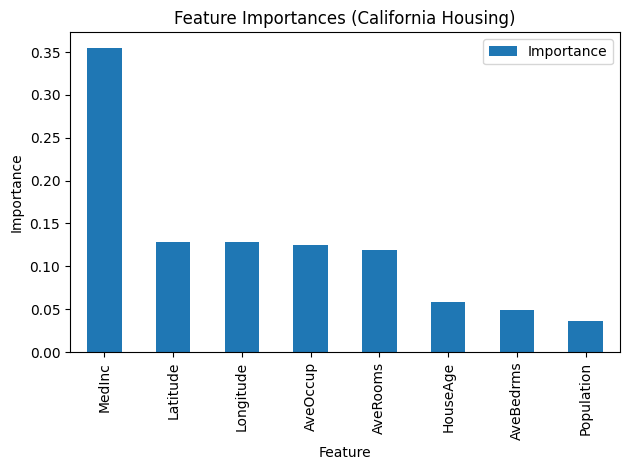

In [ ]:
# Feature Importance for Random Forest Regressor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Assuming rf_reg (RandomForestRegressor) has been trained on the California Housing dataset
# from the previous cell.

# Get feature importances from the trained RandomForestRegressor
feature_importances = rf_reg.feature_importances_

# Get feature names for the California Housing dataset
features = fetch_california_housing().feature_names
print(features)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
print(importance_df)

# Sort by importance and plot
importance_df.sort_values(by='Importance', ascending=False).plot.bar(x='Feature', y='Importance')
plt.title("Feature Importances (California Housing)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

RandomForestRegressor is an ensemble learning method for regression tasks. It builds multiple decision trees during training and outputs the average prediction of the individual trees.

Key characteristics:
- It is based on **Bagging**: Each tree is trained on a random subset (with replacement) of the training data.
- It introduces **feature randomness**: At each node split within a tree, only a random subset of features is considered. This helps to decorrelate the individual trees, further reducing variance and preventing overfitting.
- It averages the predictions of the individual trees to produce the final regression output.

Major parameters of `RandomForestRegressor`:

1.  **`n_estimators`**:
    *   **Type**: int, default=100
    *   **Description**: The number of trees in the forest. More trees generally lead to better performance but increase computation time.

2.  **`criterion`**:
    *   **Type**: {"squared_error", "absolute_error", "poisson"}, default="squared_error"
    *   **Description**: The function to measure the quality of a split.
        *   `"squared_error"`: Measures the reduction in variance.
        *   `"absolute_error"`: Measures the reduction in mean absolute error.
        *   `"poisson"`: Uses Poisson deviation.

3.  **`max_depth`**:
    *   **Type**: int, default=None
    *   **Description**: The maximum depth of the tree. If `None`, nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples. Limiting the depth can help prevent overfitting.

4.  **`min_samples_split`**:
    *   **Type**: int or float, default=2
    *   **Description**: The minimum number of samples required to split an internal node.
        *   If int, then consider `min_samples_split`.
        *   If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split.

5.  **`min_samples_leaf`**:
    *   **Type**: int or float, default=1
    *   **Description**: The minimum number of samples required to be at a leaf node. A split point is only considered if it leaves at least `min_samples_leaf` training samples in each of the left and right branches.
        *   If int, then consider `min_samples_leaf`.
        *   If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node.

6.  **`min_weight_fraction_leaf`**:
    *   **Type**: float, default=0.0
    *   **Description**: The minimum weighted fraction of the sum of total weights (all the input samples) required to be at a leaf node.

7.  **`max_features`**:
    *   **Type**: {"sqrt", "log2", None} or int or float, default=1.0
    *   **Description**: The number of features to consider when looking for the best split.
        *   If int, then consider `max_features` features at each split.
        *   If float, then `max_features` is a fraction and `int(max_features * n_features)` features are considered at each split.
        *   If `"sqrt"`, then `sqrt(n_features)` features.
        *   If `"log2"`, then `log2(n_features)` features.
        *   If `None` or `"1.0"`, then `n_features` features. This is the key difference from pure Bagging and helps decorrelate trees.

8.  **`max_leaf_nodes`**:
    *   **Type**: int, default=None
    *   **Description**: Grow trees with a maximum number of leaf nodes.

9.  **`min_impurity_decrease`**:
    *   **Type**: float, default=0.0
    *   **Description**: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

10. **`bootstrap`**:
    *   **Type**: bool, default=True
    *   **Description**: Whether bootstrap samples are used when building trees. If `False`, the whole dataset is used to build each tree.

11. **`oob_score`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether to use out-of-bag samples to estimate the generalization error. When enabled, the `oob_score_` attribute is available after fitting and provides an estimate of the R-squared score on unseen data.

12. **`n_jobs`**:
    *   **Type**: int, default=None
    *   **Description**: The number of jobs to run in parallel. `-1` uses all available processors.

13. **`random_state`**:
    *   **Type**: int, RandomState instance or None, default=None
    *   **Description**: Controls the randomness of the bootstrapping and feature sampling. Setting an int ensures reproducible results.

14. **`verbose`**:
    *   **Type**: int, default=0
    *   **Description**: Controls the verbosity when fitting and predicting.

15. **`warm_start`**:
    *   **Type**: bool, default=False
    *   **Description**: When set to `True`, reuse the solution of the previous call to fit and add more estimators to the ensemble.

These parameters allow fine-tuning the Random Forest model to balance bias and variance, control tree complexity, and manage computational resources. The `n_estimators` and `max_features` are often the most important parameters to tune.

## 🌲 Random Forest Classifier Example

Here's an example demonstrating the use of `RandomForestClassifier` for a classification task.

In [ ]:
# Random Forest Classifier Example (Classification)
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load a classification dataset (e.g., Iris)
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, oob_score=True)
rf_clf.fit(X_train, y_train)

# Evaluate the classifier
print("OOB Score:", rf_clf.oob_score_)
print("Test Accuracy:", accuracy_score(y_test, rf_clf.predict(X_test)))
print("\nClassification Report:\n", classification_report(y_test, rf_clf.predict(X_test)))

OOB Score: 0.9428571428571428
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



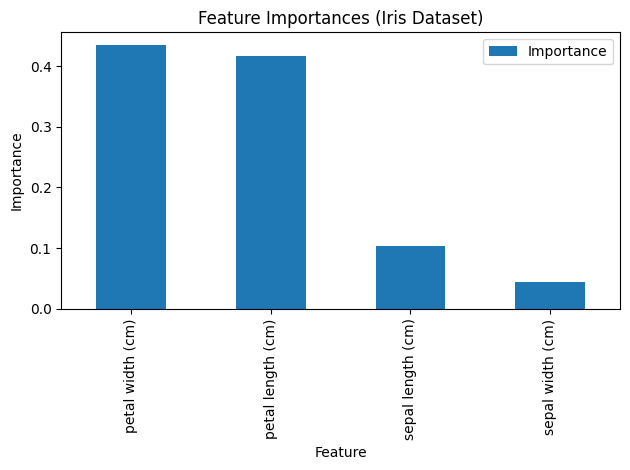

In [ ]:
# Feature Importance for Random Forest Classifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Assuming rf_clf (RandomForestClassifier) has been trained on the Iris dataset
# from the previous cell.

# Get feature importances from the trained RandomForestClassifier
feature_importances = rf_clf.feature_importances_

# Get feature names for the Iris dataset
features = load_iris().feature_names

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort by importance and plot
importance_df.sort_values(by='Importance', ascending=False).plot.bar(x='Feature', y='Importance')
plt.title("Feature Importances (Iris Dataset)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

The `RandomForestClassifier` in scikit-learn is a popular and powerful ensemble learning method specifically designed for classification tasks. It builds upon the concept of Bagging but introduces an additional layer of randomness by considering only a random subset of features at each split point within the decision trees. This feature randomness helps to decorrelate the trees, which generally leads to better generalization performance and reduced variance compared to standard Bagging with decision trees.

Here's an explanation of the major parameters of the `RandomForestClassifier`:

1.  **`n_estimators`**:
    *   **Type**: int, default=100
    *   **Description**: The number of trees in the forest. A larger number of trees generally improves performance and makes the predictions more stable, but also increases computation time and memory usage. The default was previously 10, but is now 100 in newer versions of scikit-learn.

2.  **`criterion`**:
    *   **Type**: {"gini", "entropy", "log_loss"}, default="gini"
    *   **Description**: The function to measure the quality of a split.
        *   `"gini"`: Refers to the Gini impurity.
        *   `"entropy"`: Refers to the information gain (or loss).
        *   `"log_loss"`: Refers to cross-entropy.
    *   These are impurity measures used to evaluate how well a split separates the classes.

3.  **`max_depth`**:
    *   **Type**: int, default=None
    *   **Description**: The maximum depth of the trees. If `None`, nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples. Limiting depth can help prevent overfitting.

4.  **`min_samples_split`**:
    *   **Type**: int or float, default=2
    *   **Description**: The minimum number of samples required to split an internal node.
        *   If int, then consider `min_samples_split` as the minimum number.
        *   If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split.
    *   This parameter controls the minimum size of a node before it can be split further.

5.  **`min_samples_leaf`**:
    *   **Type**: int or float, default=1
    *   **Description**: The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least `min_samples_leaf` training samples in each of the left and right branches.
        *   If int, then consider `min_samples_leaf` as the minimum number.
        *   If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node.
    *   This ensures that leaf nodes are not too small, which can help with generalization.

6.  **`min_weight_fraction_leaf`**:
    *   **Type**: float, default=0.0
    *   **Description**: The minimum weighted fraction of the sum total of weights required to be at a leaf node. Samples are equally weighted if sample_weight is not provided.

7.  **`max_features`**:
    *   **Type**: {"sqrt", "log2", None}, int or float, default="sqrt"
    *   **Description**: The number of features to consider when looking for the best split.
        *   If int, then consider `max_features` features at each split.
        *   If float, then `max_features` is a fraction and `int(max_features * n_features)` features are considered.
        *   If `"sqrt"`, then `max_features = sqrt(n_features)`. This is the default in recent scikit-learn versions.
        *   If `"log2"`, then `max_features = log2(n_features)`.
        *   If `None`, then `max_features = n_features` (i.e., all features are considered, similar to standard Bagging Decision Trees).
    *   This is a key parameter that introduces the feature randomness specific to Random Forests.

8.  **`max_leaf_nodes`**:
    *   **Type**: int, default=None
    *   **Description**: Grow trees with a maximum number of leaf nodes. If `None`, then unlimited number of leaf nodes.

9.  **`min_impurity_decrease`**:
    *   **Type**: float, default=0.0
    *   **Description**: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

10. **`bootstrap`**:
    *   **Type**: bool, default=True
    *   **Description**: Whether bootstrap samples are used when building trees. If `False`, the whole dataset is used to build each tree. `True` is the standard for Random Forests.

11. **`oob_score`**:
    *   **Type**: bool, default=False
    *   **Description**: Whether to use out-of-bag samples to estimate the generalization error. Setting this to `True` calculates the OOB accuracy score on the training data, providing an estimate of the model's performance on unseen data without needing a separate validation set.

12. **`n_jobs`**:
    *   **Type**: int, default=None
    *   **Description**: The number of jobs to run in parallel. `None` means 1. `-1` means using all processors. This is very useful for speeding up training as tree building is independent.

13. **`random_state`**:
    *   **Type**: int, RandomState instance or None, default=None
    *   **Description**: Controls the randomness of bootstrapping (if `bootstrap=True`), the sampling of features at each split (if `max_features < n_features`), and the split points. Pass an int for reproducible results.

14. **`verbose`**:
    *   **Type**: int, default=0
    *   **Description**: Controls the verbosity when fitting and predicting.

15. **`warm_start`**:
    *   **Type**: bool, default=False
    *   **Description**: When set to `True`, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just erase the previous solution.

16. **`class_weight`**:
    *   **Type**: {"balanced", "balanced_subsample"}, dict or list of dicts, default=None
    *   **Description**: Weights associated with classes in the form `{class_label: weight}`. Use `"balanced"` to automatically adjust weights inversely proportional to class frequencies in the input data. Use `"balanced_subsample"` to use the `"balanced"` mode only on the bootstrap subsample.

17. **`ccp_alpha`**:
    *   **Type**: non-negative float, default=0.0
    *   **Description**: Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than `ccp_alpha` will be chosen.

These parameters allow fine-tuning of the Random Forest model to balance bias and variance, control the size and complexity of the trees, manage the randomness in sampling, and handle computational resources.

## 💡 Summary and Conclusion

Bagging and Random Forests are powerful ensemble techniques that improve the stability and accuracy of machine learning models by reducing variance.

- **Bagging** trains multiple models on bootstrapped samples of the data.
- **Random Forest** builds upon bagging by adding feature randomness at each split in decision trees, further decorrelating the trees and improving robustness.

These methods are widely used in various machine learning tasks and are excellent tools to have in your data science toolkit.

## ⚙️ Hyperparameter Tuning for Random Forest

Hyperparameter tuning is crucial for optimizing the performance of Random Forest models. Some key hyperparameters to consider include:

- **`n_estimators`**: The number of trees in the forest. Increasing this generally improves performance but also increases computation time.
- **`max_features`**: The number of features to consider when looking for the best split.
- **`max_depth`**: The maximum depth of the trees.
- **`min_samples_split`**: The minimum number of samples required to split an internal node.
- **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node.
- **`bootstrap`**: Whether bootstrap samples are used when building trees.

We can use techniques like **Grid Search** or **Randomized Search** to find the best combination of hyperparameters.

In [ ]:
# Hyperparameter Tuning Example (using GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,  # 5-fold cross-validation
                           scoring='accuracy',
                           n_jobs=-1) # Use all available cores

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# Evaluate on the test set with the best estimator
best_rf_clf = grid_search.best_estimator_
test_accuracy = best_rf_clf.score(X_test, y_test)
print("Test Accuracy with Best Estimator:", test_accuracy)

KeyboardInterrupt: 

# **What is the actual difference between Bagging and Random Forest?**

They are closely related, but not exactly the same. Below is a structured explanation that separates their concepts, assumptions, and mechanisms.

---

## ✅ **Core Difference**

| Aspect               | Bagging (Bootstrap Aggregating)                                         | Random Forest                                                                              |
| -------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------------------------------ |
| Base algorithm       | Any high-variance estimator (commonly decision trees)                   | Specifically decision trees                                                                |
| Sampling of data     | Rows sampled with replacement (bootstrapped samples)                    | Same                                                                                       |
| Sampling of features | Usually all features are available                                      | Random subset of features is considered at each split                                      |
| Purpose              | Reduce variance by averaging over multiple models                       | Reduce variance **and correlation** among trees by both bootstrapping samples and features |
| Diversity mechanism  | Different data samples for each estimator                               | Different data samples and random subsets of features at splits                            |
| Interpretability     | More interpretable than Random Forest because splits are not randomized | Slightly less interpretable because of feature randomness                                  |
| Implementation       | BaggingClassifier/BaggingRegressor                                      | RandomForestClassifier/RandomForestRegressor                                               |

---

## ✅ In-depth explanation

### ➤ **Bagging**

* Trains multiple estimators on different random subsets of the training data.
* Every estimator has access to **all features** when making decisions.
* Works by averaging outputs to reduce variance and overfitting.
* Example: `BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100)`

### ➤ **Random Forest**

* Builds on Bagging but adds randomness at the feature level.
* At each split in the decision tree, only a random subset of features is considered.
* This reduces correlation between trees more effectively and avoids some overfitting.
* Example: `RandomForestClassifier(n_estimators=100, max_features='sqrt')`

---

## ✅ Why is Random Forest more effective?

* Trees in Bagging can be very similar if certain features dominate the data patterns.
* Random Forest ensures that trees explore different feature splits, making them decorrelated.
* This leads to better generalization and often better performance on unseen data.

---

## ✅ Visual Analogy

* **Bagging** is like having 100 different students take the same exam but each given a slightly different set of questions (bootstrapped data), though they can use all available tools (features).

* **Random Forest** is like having 100 students take the same exam, each given a slightly different set of questions (bootstrapped data), and also each having access to only a subset of tools (features) to answer questions.

---

## ✅ Practical Differences

1. **Use Bagging when:**

   * You want variance reduction and are okay with trees being similar.
   * Your dataset is relatively small or features are not highly correlated.

2. **Use Random Forest when:**

   * You want both variance and correlation reduction.
   * Your dataset has many features or some features dominate patterns.

---

## ✅ Summary

✔ Bagging is a general ensemble method that trains models on bootstrapped samples of data.
✔ Random Forest is a specialized form of Bagging that introduces additional randomness by selecting random subsets of features at each split.
✔ The key difference is in **feature sampling**—Random Forest deliberately decorrelates trees more strongly.
✔ Random Forest often yields better accuracy, especially in datasets with correlated features or complex patterns.

---


# Resources:

https://www.datacamp.com/tutorial/what-bagging-in-machine-learning-a-guide-with-examples

https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/